
# F4 · Métricas de posición partidaria y afinidad entre pares

## Objetivo

Presentar y visualizar los resultados ya generados por los módulos de F4 para:

1. **Posición partidaria**: posición por partido y votación (`b_pj`) y perfil partidario (`P_p`).
2. **Afinidad entre pares**: co-votos, acuerdo nominal y distancia de Hamming.
3. **Sensibilidad partidaria**: efecto de retirar una votación sobre `P_p`.

Este notebook **no reimplementa las fórmulas**. Consume las salidas reproducibles generadas por `src/analisis/posicion_partidos.py`, `src/analisis/afinidad.py` y `src/analisis/sensibilidad.py`.

### Cautelas de interpretación

- `P_p` representa una **posición relativa dentro del corpus analizado**; no se interpreta automáticamente como una etiqueta ideológica.
- La dispersión de `d1` dentro de un partido es descriptiva y **no equivale a cohesión**.
- La afinidad solo se calcula sobre **co-votos**; dos celdas sin decisión registrada no cuentan como acuerdo.
- La cobertura observada no se interpreta como asistencia cuando no existe un padrón verificable.


In [1]:

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Permite ejecutar desde la raíz del repositorio o desde F4/notebooks.
raiz = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "F4").exists() and (p / "pyproject.toml").exists()
    ),
    None,
)
if raiz is None:
    raise RuntimeError("No se encontró la raíz del repositorio.")

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

rutas = {
    "posicion": raiz / "F4/data/results/partidos/posicion_partidaria.csv",
    "afinidad": raiz / "F4/data/results/pares/afinidad_diputados.csv",
    "hamming": raiz / "F4/data/results/pares/matriz_hamming.csv",
    "sensibilidad": raiz / "F4/data/reports/sensibilidad.csv",
    "votos": raiz / "F4/data/processed/votos_codificados.csv",
    "figuras": raiz / "F4/figures/partidos_afinidad",
}
rutas["figuras"].mkdir(parents=True, exist_ok=True)

for nombre, ruta in rutas.items():
    if nombre != "figuras" and not ruta.exists():
        raise FileNotFoundError(f"No existe {nombre}: {ruta}")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("Raíz:", raiz)
print("Figuras:", rutas["figuras"])


Raíz: /home/sebastian/Escritorio/magister/proyectos/grupo_1_programacion_ciencia_datos
Figuras: /home/sebastian/Escritorio/magister/proyectos/grupo_1_programacion_ciencia_datos/F4/figures/partidos_afinidad



## 1. Carga y validación de resultados

Se cargan las tablas finales generadas por los módulos analíticos. Se separan las filas de posición por partido × votación y las filas de resumen por partido.


In [2]:

posicion = pd.read_csv(rutas["posicion"])
afinidad = pd.read_csv(rutas["afinidad"])
matriz_hamming = pd.read_csv(rutas["hamming"], index_col="diputado_id")
sensibilidad = pd.read_csv(rutas["sensibilidad"])
votos = pd.read_csv(rutas["votos"])

partido_votacion = posicion.loc[posicion["nivel"].eq("partido_votacion")].copy()
partidos = posicion.loc[posicion["nivel"].eq("partido")].copy()

assert not posicion.empty
assert not afinidad.empty
assert matriz_hamming.shape[0] == matriz_hamming.shape[1]
assert {"P_p", "n_votaciones", "mediana_d1", "iqr_d1"}.issubset(partidos.columns)
assert {"acuerdo", "hamming", "n_covotos", "incluido"}.issubset(afinidad.columns)

resumen_carga = pd.Series({
    "filas_posicion_partidaria": len(posicion),
    "partidos_resumen": len(partidos),
    "partido_x_votacion": len(partido_votacion),
    "pares_totales": len(afinidad),
    "pares_incluidos": int(afinidad["incluido"].fillna(False).sum()),
    "diputados_matriz_hamming": matriz_hamming.shape[0],
    "filas_sensibilidad": len(sensibilidad),
})
display(resumen_carga)


filas_posicion_partidaria      281
partidos_resumen                22
partido_x_votacion             259
pares_totales                11325
pares_incluidos               9141
diputados_matriz_hamming       151
filas_sensibilidad           16887
dtype: int64


## 2. Posición partidaria

`P_p` resume la posición relativa del partido dando igual peso a cada votación válida. La tabla mantiene `n_votaciones` como denominador efectivo y la mediana/IQR de `d1` como descripción de la distribución de sus integrantes.

Los partidos sin suficientes votaciones válidas permanecen en la tabla con `P_p = NA` y su motivo de no estimabilidad.


In [3]:

columnas_partido = [
    "partido_id", "partido_nombre", "partido_alias",
    "P_p", "n_votaciones", "mediana_d1", "iqr_d1",
    "razon_NA", "estado",
]
tabla_partidos = partidos[columnas_partido].copy()
tabla_partidos = tabla_partidos.sort_values(["P_p", "partido_alias"], na_position="last")
display(tabla_partidos)


,partido_id,partido_nombre,partido_alias,P_p,n_votaciones,mediana_d1,iqr_d1,razon_NA,estado
278,DC,Partido Demócrata Cristiano,DC,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
267,PAH,Partido Acción Humanista,PAH,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
264,PC,Partido Comunista,PC,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
265,PL,Partido Liberal de Chile,PL,-0.726106,13.0,-0.726106,0.000000,NaN,DESCRIPTIVO_SIN_PADRON
270,PPD,Partido Por la Democracia,PPD,-0.726106,13.0,-0.726106,0.005699,NaN,DESCRIPTIVO_SIN_PADRON
259,PS,Partido Socialista,PS,-0.726106,13.0,-0.726106,0.011398,NaN,DESCRIPTIVO_SIN_PADRON
268,PCS,Partido Convergencia Social,PCS,-0.714709,12.0,-0.726106,0.005699,NaN,DESCRIPTIVO_SIN_PADRON
271,PR,Partido Radical de Chile,PR,-0.714709,12.0,-0.720407,0.005699,NaN,DESCRIPTIVO_SIN_PADRON
274,RD,Revolución Democrática,RD,-0.714709,12.0,-0.726106,0.002849,NaN,DESCRIPTIVO_SIN_PADRON
260,IND,Independientes,IND,-0.131459,13.0,-0.638218,1.959769,NaN,DESCRIPTIVO_SIN_PADRON


### 2.1. Perfil relativo por partido

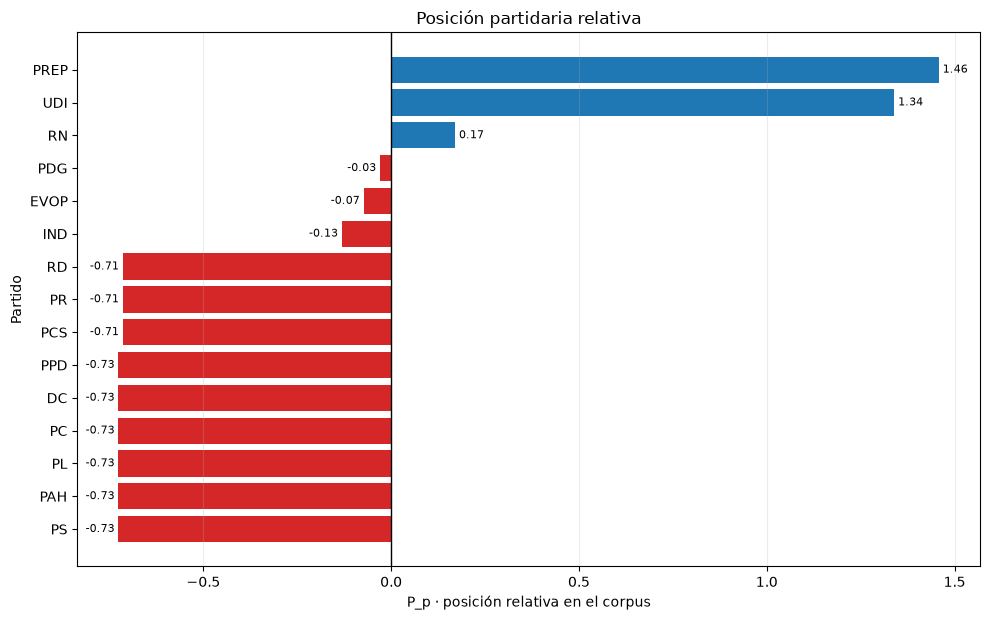

Guardada: F4/figures/partidos_afinidad/posicion_partidaria.png


In [4]:

estimables = partidos.loc[partidos["P_p"].notna()].copy().sort_values("P_p")

fig, ax = plt.subplots(figsize=(10, max(5, 0.42 * len(estimables))))
colors = ["#d62728" if v < 0 else "#1f77b4" for v in estimables["P_p"]]
ax.barh(estimables["partido_alias"], estimables["P_p"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("P_p · posición relativa en el corpus")
ax.set_ylabel("Partido")
ax.set_title("Posición partidaria relativa")
ax.grid(axis="x", alpha=0.25)

for y, v in enumerate(estimables["P_p"]):
    ha = "right" if v < 0 else "left"
    offset = -0.01 if v < 0 else 0.01
    ax.text(v + offset, y, f"{v:.2f}", va="center", ha=ha, fontsize=8)

fig.tight_layout()

ruta_fig = rutas["figuras"] / "posicion_partidaria.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))



La figura ordena visualmente los valores de `P_p`. El signo y la magnitud se interpretan únicamente respecto del eje B-Call construido para este corpus; no constituyen por sí mismos una clasificación ideológica general.


En las figuras de posición partidaria se usa **azul** para valores negativos de `P_p` y **rojo** para valores positivos.

En las figuras de posición partidaria se usa **azul** para valores negativos de `P_p` y **rojo** para valores positivos.

### 2.2. Posición y heterogeneidad descriptiva de integrantes

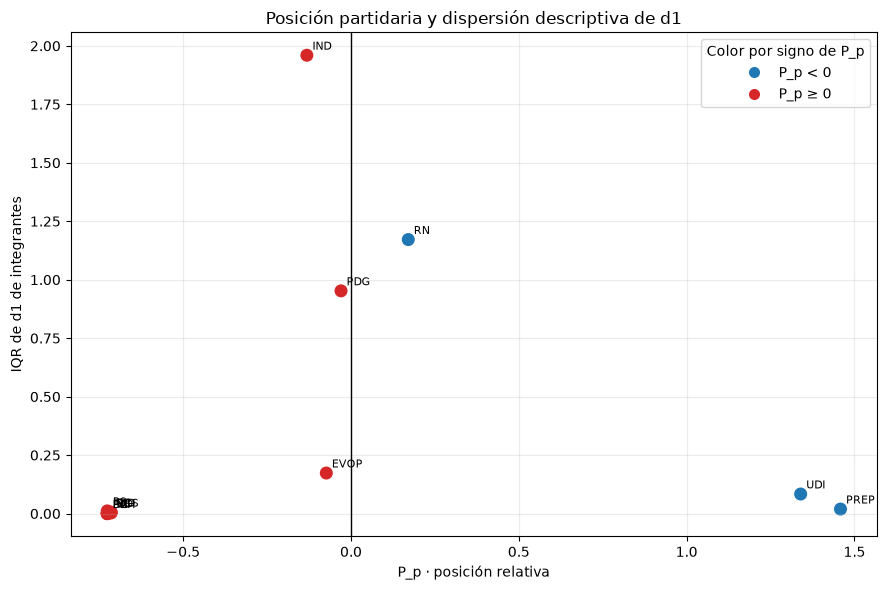

Guardada: F4/figures/partidos_afinidad/posicion_partidaria_dispersion_d1.png


In [5]:

estimables_disp = estimables.loc[
    estimables["mediana_d1"].notna() & estimables["iqr_d1"].notna()
].copy()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#d62728" if v < 0 else "#1f77b4" for v in estimables_disp["P_p"]]
ax.scatter(
    estimables_disp["P_p"],
    estimables_disp["iqr_d1"],
    s=70,
    c=colors,
)
for _, fila in estimables_disp.iterrows():
    ax.annotate(
        fila["partido_alias"],
        (fila["P_p"], fila["iqr_d1"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("P_p · posición relativa")
ax.set_ylabel("IQR de d1 de integrantes")
ax.set_title("Posición partidaria y dispersión descriptiva de d1")
ax.grid(alpha=0.25)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='P_p < 0', markerfacecolor="#1f77b4", markersize=9),
    Line2D([0], [0], marker='o', color='w', label='P_p ≥ 0', markerfacecolor="#d62728", markersize=9),
]
ax.legend(handles=legend_elements, title="Color por signo de P_p", loc="best")

fig.tight_layout()

ruta_fig = rutas["figuras"] / "posicion_partidaria_dispersion_d1.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))



El IQR de `d1` muestra dispersión interna de posiciones individuales. No sustituye los índices de cohesión partidaria (AI, Rice o entropía), que se analizan por separado.


### 2.3. Posición por partido × votación

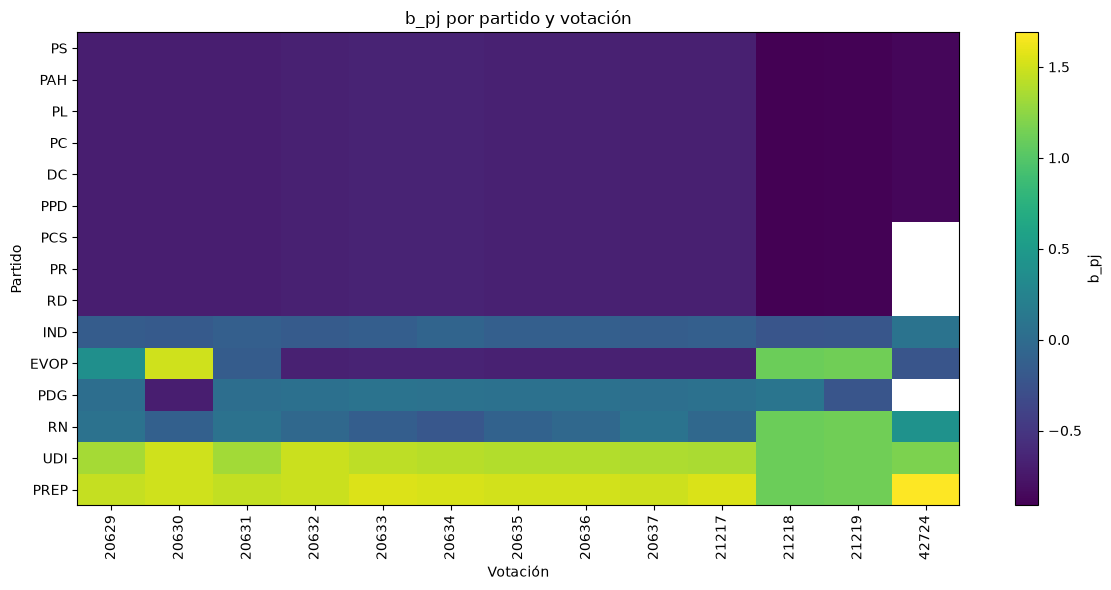

Guardada: F4/figures/partidos_afinidad/posicion_partido_votacion.png


In [6]:

pv_validas = partido_votacion.loc[
    partido_votacion["incluido"].fillna(False) & partido_votacion["b_pj"].notna()
].copy()

tabla_calor = pv_validas.pivot_table(
    index="partido_alias",
    columns="votacion_id",
    values="b_pj",
    aggfunc="first",
)
orden_partidos = (
    estimables.set_index("partido_alias")["P_p"]
    .sort_values()
    .index
)
tabla_calor = tabla_calor.reindex([p for p in orden_partidos if p in tabla_calor.index])

fig, ax = plt.subplots(figsize=(12, max(5, 0.4 * len(tabla_calor))))
imagen = ax.imshow(tabla_calor.to_numpy(dtype=float), aspect="auto")
ax.set_yticks(np.arange(len(tabla_calor.index)))
ax.set_yticklabels(tabla_calor.index)
ax.set_xticks(np.arange(len(tabla_calor.columns)))
ax.set_xticklabels([str(int(x)) if pd.notna(x) else "" for x in tabla_calor.columns], rotation=90)
ax.set_xlabel("Votación")
ax.set_ylabel("Partido")
ax.set_title("b_pj por partido y votación")
fig.colorbar(imagen, ax=ax, label="b_pj")
fig.tight_layout()

ruta_fig = rutas["figuras"] / "posicion_partido_votacion.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))



## 3. Afinidad entre pares

El análisis considera solo votaciones compartidas con decisión observada para ambos diputados:

- `acuerdo`: proporción de co-votos con la misma opción nominal.
- `hamming`: proporción de co-votos en que difieren.
- `n_covotos`: denominador efectivo del par.
- `incluido`: indica si el par alcanza el mínimo metodológico de co-votos.

La abstención es una categoría nominal propia. Los faltantes simultáneos no se consideran coincidencia.


Para facilitar la interpretación visual, la figura de cobertura/Hamming agrega una línea roja con la **mediana de Hamming por número de co-votos**.

Para facilitar la lectura, la figura `hamming_covotos.png` ahora muestra puntos azules para pares individuales y una línea roja con la mediana de Hamming por número de co-votos.

In [7]:

resumen_afinidad = pd.Series({
    "pares_totales": len(afinidad),
    "pares_incluidos": int(afinidad["incluido"].fillna(False).sum()),
    "pares_sin_covotos": int(afinidad["n_covotos"].eq(0).sum()),
    "mediana_covotos_pares_incluidos": float(
        afinidad.loc[afinidad["incluido"].fillna(False), "n_covotos"].median()
    ),
    "mediana_acuerdo_pares_incluidos": float(
        afinidad.loc[afinidad["incluido"].fillna(False), "acuerdo"].median()
    ),
    "mediana_hamming_pares_incluidos": float(
        afinidad.loc[afinidad["incluido"].fillna(False), "hamming"].median()
    ),
})
display(resumen_afinidad)


pares_totales                      11325.000000
pares_incluidos                     9141.000000
pares_sin_covotos                    423.000000
mediana_covotos_pares_incluidos       14.000000
mediana_acuerdo_pares_incluidos        0.733333
mediana_hamming_pares_incluidos        0.266667
dtype: float64

### 3.1. Distribución de acuerdo y Hamming

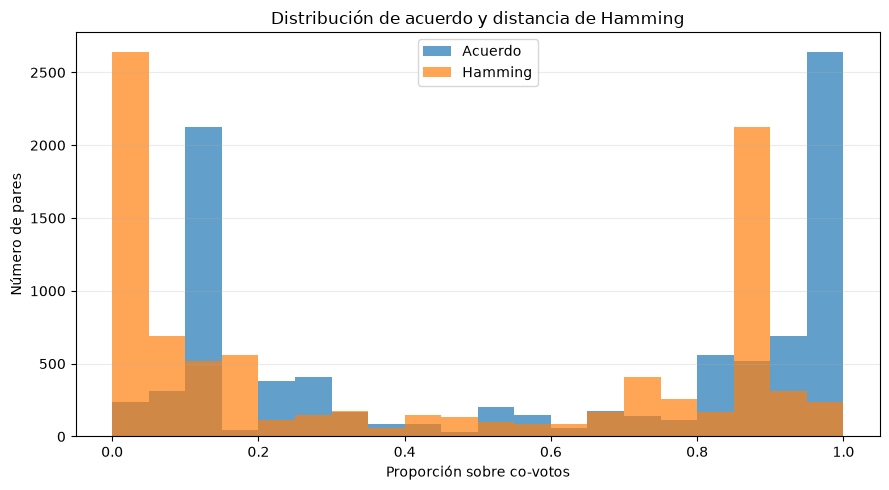

Guardada: F4/figures/partidos_afinidad/afinidad_distribucion.png


In [8]:

pares_validos = afinidad.loc[afinidad["incluido"].fillna(False)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pares_validos["acuerdo"].dropna(), bins=np.linspace(0, 1, 21), alpha=0.7, label="Acuerdo")
ax.hist(pares_validos["hamming"].dropna(), bins=np.linspace(0, 1, 21), alpha=0.7, label="Hamming")
ax.set_xlabel("Proporción sobre co-votos")
ax.set_ylabel("Número de pares")
ax.set_title("Distribución de acuerdo y distancia de Hamming")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

ruta_fig = rutas["figuras"] / "afinidad_distribucion.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))


### 3.2. Relación entre cobertura conjunta y distancia

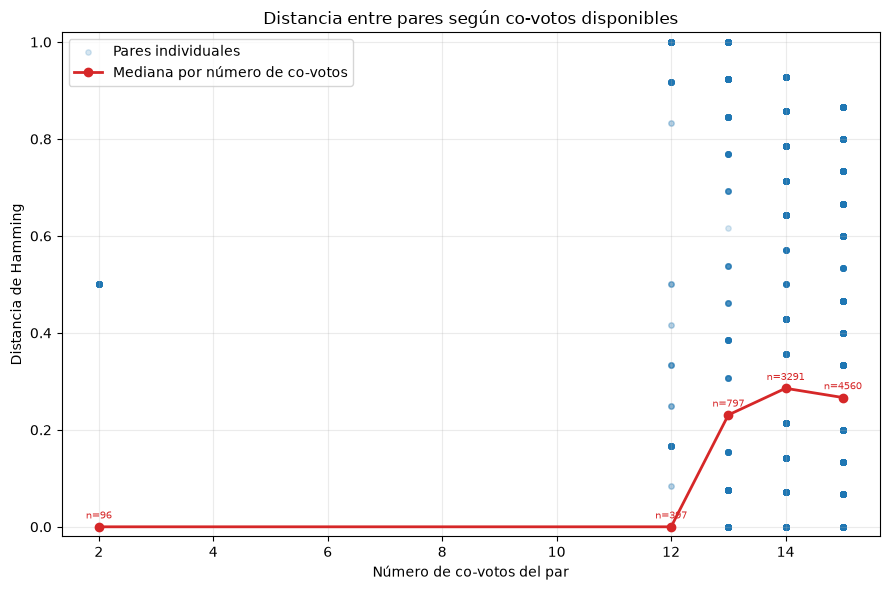

Guardada: F4/figures/partidos_afinidad/hamming_covotos.png


In [9]:

pares_validos = afinidad.loc[afinidad["incluido"].fillna(False)].copy()
pares_validos["n_covotos"] = pd.to_numeric(pares_validos["n_covotos"], errors="coerce")
pares_validos["hamming"] = pd.to_numeric(pares_validos["hamming"], errors="coerce")
pares_validos = pares_validos.dropna(subset=["n_covotos", "hamming"])

resumen_cov = (
    pares_validos.groupby("n_covotos", as_index=False)
    .agg(
        mediana_hamming=("hamming", "median"),
        n_pares=("hamming", "size"),
    )
    .sort_values("n_covotos")
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    pares_validos["n_covotos"],
    pares_validos["hamming"],
    s=15,
    alpha=0.18,
    color="#1f77b4",
    label="Pares individuales",
)
ax.plot(
    resumen_cov["n_covotos"],
    resumen_cov["mediana_hamming"],
    marker="o",
    linewidth=2,
    color="#d62728",
    label="Mediana por número de co-votos",
)
ax.set_xlabel("Número de co-votos del par")
ax.set_ylabel("Distancia de Hamming")
ax.set_title("Distancia entre pares según co-votos disponibles")
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(loc="best")

for _, fila in resumen_cov.iterrows():
    ax.annotate(
        f"n={int(fila['n_pares'])}",
        (fila["n_covotos"], fila["mediana_hamming"]),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=7,
        color="#d62728",
    )

fig.tight_layout()

ruta_fig = rutas["figuras"] / "hamming_covotos.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))


             q25  mediana    q75  n_pares  pct_cero
n_covotos                                          
2          0.000    0.000  0.500       96    51.042
12         0.000    0.000  1.000      397    53.149
13         0.000    0.231  0.923      797    32.748
14         0.000    0.286  0.857     3291    30.356
15         0.067    0.267  0.867     4560    24.627

Pares con menos de 10 co-votos: 96 de 9141


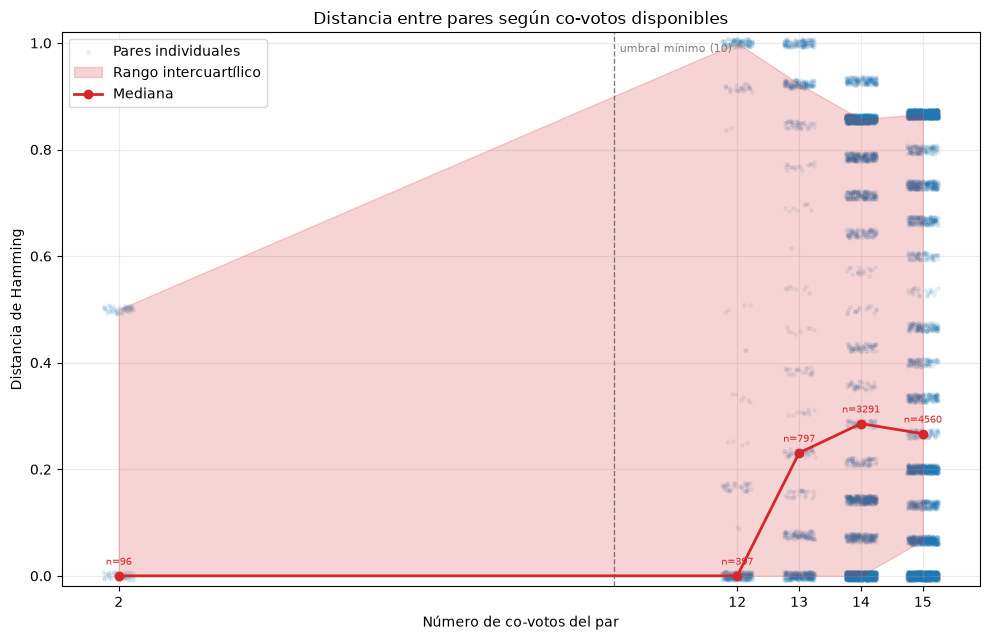

Guardada: F4/figures/partidos_afinidad/hamming_covotos2.png


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARÁMETRO: mínimo de co-votos para considerar fiable un par
# ============================================================
MIN_COVOTOS = 10

# --- Datos ---
pares_validos = afinidad.loc[afinidad["incluido"].fillna(False)].copy()
pares_validos["n_covotos"] = pd.to_numeric(pares_validos["n_covotos"], errors="coerce")
pares_validos["hamming"] = pd.to_numeric(pares_validos["hamming"], errors="coerce")
pares_validos = pares_validos.dropna(subset=["n_covotos", "hamming"])

# Resumen por número de co-votos
grupos = pares_validos.groupby("n_covotos")["hamming"]
resumen_cov = pd.DataFrame({
    "q25": grupos.quantile(0.25),
    "mediana": grupos.median(),
    "q75": grupos.quantile(0.75),
    "n_pares": grupos.size(),
    "pct_cero": grupos.apply(lambda s: (s == 0).mean() * 100),
}).sort_index()

print(resumen_cov.round(3))
print(f"\nPares con menos de {MIN_COVOTOS} co-votos: "
      f"{(pares_validos['n_covotos'] < MIN_COVOTOS).sum()} "
      f"de {len(pares_validos)}")

# --- Jitter para evitar overplotting ---
rng = np.random.default_rng(0)
x_jit = pares_validos["n_covotos"] + rng.uniform(-0.25, 0.25, len(pares_validos))
y_jit = pares_validos["hamming"] + rng.uniform(-0.008, 0.008, len(pares_validos))

# ============================================================
# FIGURA 1: distancia vs número de co-votos
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6.5))

ax.scatter(x_jit, y_jit, s=6, alpha=0.08, color="#1f77b4",
           label="Pares individuales", zorder=1)
ax.fill_between(resumen_cov.index, resumen_cov["q25"], resumen_cov["q75"],
                color="#d62728", alpha=0.2, label="Rango intercuartílico", zorder=2)
ax.plot(resumen_cov.index, resumen_cov["mediana"], marker="o", color="#d62728",
        lw=2, label="Mediana", zorder=3)

# Umbral mínimo
ax.axvline(MIN_COVOTOS, color="gray", ls="--", lw=1, zorder=0)
ax.text(MIN_COVOTOS + 0.1, 1.0, f"umbral mínimo ({MIN_COVOTOS})",
        fontsize=8, color="gray", va="top")

# Etiquetas con n de pares
for n_cov, fila in resumen_cov.iterrows():
    ax.annotate(f"n={int(fila['n_pares'])}",
                (n_cov, fila["mediana"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=7, color="#d62728")

ax.set_xlabel("Número de co-votos del par")
ax.set_ylabel("Distancia de Hamming")
ax.set_title("Distancia entre pares según co-votos disponibles")
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(resumen_cov.index)
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
fig.tight_layout()

ruta_fig = rutas["figuras"] / "hamming_covotos2.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))


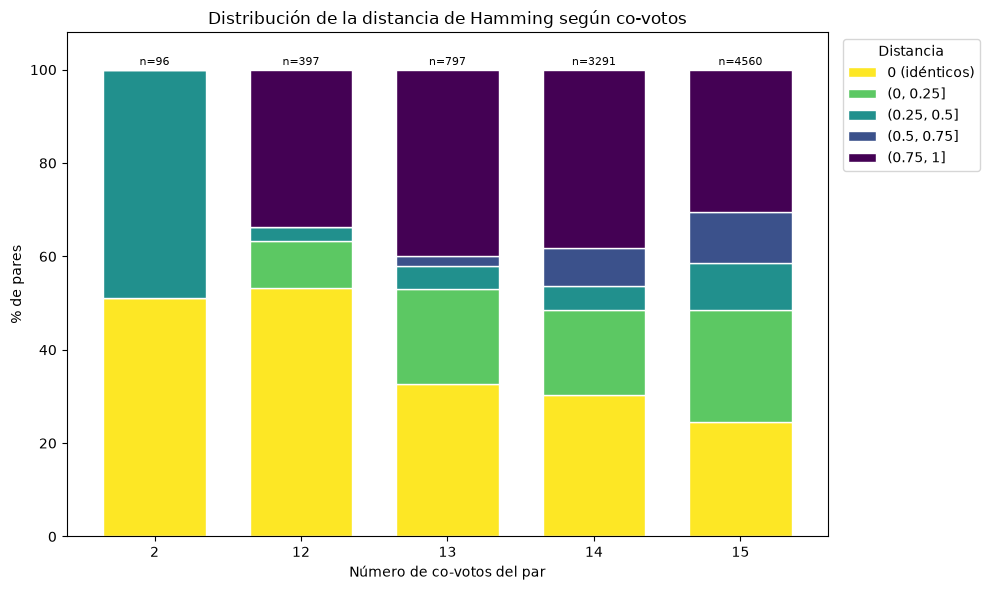

Guardada: F4/figures/partidos_afinidad/hamming_covotos_rangos.png


In [11]:
# ============================================================
# FIGURA 2: distribución por rangos de distancia
# ============================================================
bins = [-0.001, 0.0, 0.25, 0.5, 0.75, 1.0]
etiquetas = ["0 (idénticos)", "(0, 0.25]", "(0.25, 0.5]", "(0.5, 0.75]", "(0.75, 1]"]
pares_validos["rango"] = pd.cut(pares_validos["hamming"], bins=bins, labels=etiquetas)

tabla = (
    pares_validos.groupby(["n_covotos", "rango"], observed=False)
    .size()
    .unstack(fill_value=0)
)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
tabla_pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis_r",
               edgecolor="white", width=0.7)

# n de pares encima de cada barra
for i, (n_cov, total) in enumerate(tabla.sum(axis=1).items()):
    ax.text(i, 101, f"n={int(total)}", ha="center", fontsize=8)

ax.set_xlabel("Número de co-votos del par")
ax.set_ylabel("% de pares")
ax.set_title("Distribución de la distancia de Hamming según co-votos")
ax.set_ylim(0, 108)
ax.set_xticklabels([int(x) for x in tabla_pct.index], rotation=0)
ax.legend(title="Distancia", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()

ruta_fig2 = rutas["figuras"] / "hamming_covotos_rangos.png"
fig.savefig(ruta_fig2, dpi=160, bbox_inches="tight")
plt.show()
print("Guardada:", ruta_fig2.relative_to(raiz))

### 3.3. Distancia media de Hamming entre partidos

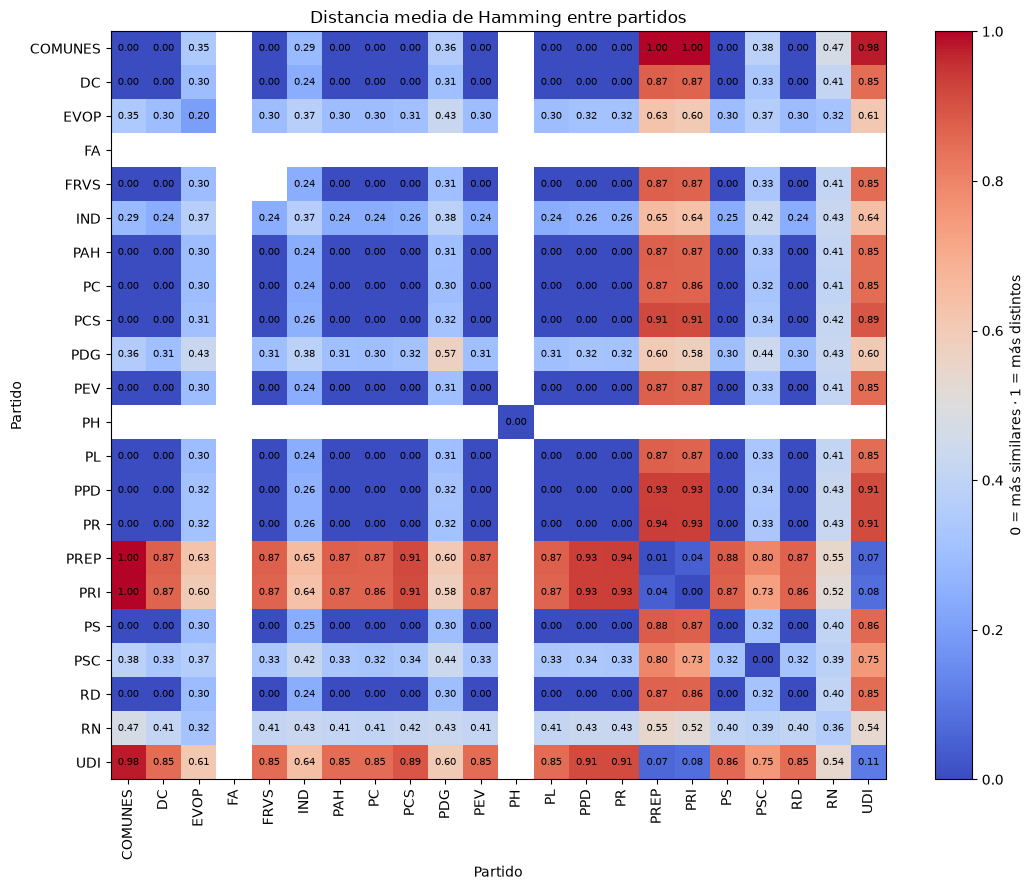

Guardada: F4/figures/partidos_afinidad/matriz_hamming.png


In [12]:

matriz_hamming.index = pd.Index(pd.to_numeric(matriz_hamming.index, errors="raise").astype(int))
matriz_hamming.columns = pd.Index(pd.to_numeric(matriz_hamming.columns, errors="raise").astype(int))

partido_modal = (
    votos.dropna(subset=["partido_alias"])
    .groupby("diputado_id")["partido_alias"]
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
)

diputados_con_partido = [d for d in matriz_hamming.index if d in partido_modal.index]
sub = matriz_hamming.loc[diputados_con_partido, diputados_con_partido].copy()
partidos_unicos = sorted(partido_modal.loc[diputados_con_partido].dropna().unique().tolist())

promedio_partido = pd.DataFrame(index=partidos_unicos, columns=partidos_unicos, dtype=float)
for p_i in partidos_unicos:
    ids_i = partido_modal[partido_modal.eq(p_i)].index.intersection(sub.index)
    for p_j in partidos_unicos:
        ids_j = partido_modal[partido_modal.eq(p_j)].index.intersection(sub.columns)
        bloque = sub.loc[ids_i, ids_j].copy()
        valores = bloque.to_numpy(dtype=float)

        if p_i == p_j and len(ids_i) > 1:
            mask = ~np.eye(len(ids_i), dtype=bool)
            vals = valores[mask]
        else:
            vals = valores.ravel()

        vals = vals[~np.isnan(vals)]
        promedio_partido.loc[p_i, p_j] = np.nan if len(vals) == 0 else float(vals.mean())

promedio_partido = promedio_partido.astype(float)

fig, ax = plt.subplots(figsize=(11, 9))
img = ax.imshow(promedio_partido.to_numpy(dtype=float), vmin=0, vmax=1, cmap="coolwarm", aspect="auto")
ax.set_xticks(np.arange(len(promedio_partido.columns)))
ax.set_xticklabels(promedio_partido.columns, rotation=90)
ax.set_yticks(np.arange(len(promedio_partido.index)))
ax.set_yticklabels(promedio_partido.index)
ax.set_xlabel("Partido")
ax.set_ylabel("Partido")
ax.set_title("Distancia media de Hamming entre partidos")

for i in range(promedio_partido.shape[0]):
    for j in range(promedio_partido.shape[1]):
        val = promedio_partido.iat[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

cbar = fig.colorbar(img, ax=ax)
cbar.set_label("0 = más similares · 1 = más distintos")
fig.tight_layout()

ruta_fig = rutas["figuras"] / "matriz_hamming.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))


### 3.4. Pares con mayor cantidad de co-votos

In [13]:
nombres = (
    votos.sort_values(["diputado_id", "fecha"])
    .drop_duplicates("diputado_id")
    .set_index("diputado_id")
)
def nombre_diputado(diputado_id):
    if diputado_id not in nombres.index:
        return str(diputado_id)
    fila = nombres.loc[diputado_id]
    partes = [
        str(fila.get("nombre", "")).strip(),
        str(fila.get("apellido_paterno", "")).strip(),
        str(fila.get("apellido_materno", "")).strip(),
    ]
    nombre = " ".join(p for p in partes if p and p.lower() != "nan")
    return f"{diputado_id} · {nombre}" if nombre else str(diputado_id)

muestra_pares = pares_validos.sort_values(
    ["n_covotos", "hamming"],
    ascending=[False, True],
).head(20).copy()

muestra_pares["diputado_i_nombre"] = muestra_pares["diputado_i"].map(nombre_diputado)
muestra_pares["diputado_j_nombre"] = muestra_pares["diputado_j"].map(nombre_diputado)

display(
    muestra_pares[
        [
            "diputado_i_nombre",
            "diputado_j_nombre",
            "n_covotos",
            "acuerdo",
            "hamming",
            "acuerdo_sin_unanimes",
            "hamming_sin_unanimes",
        ]
    ]
)


,diputado_i_nombre,diputado_j_nombre,n_covotos,acuerdo,hamming,acuerdo_sin_unanimes,hamming_sin_unanimes
376,815 · Sergio Bobadilla Muñoz,1111 · Fernando Bórquez Montecinos,15,1.0,0.0,1.0,0.0
391,815 · Sergio Bobadilla Muñoz,1126 · Felipe Donoso Castro,15,1.0,0.0,1.0,0.0
398,815 · Sergio Bobadilla Muñoz,1135 · Johannes Kaiser Barents-Von Hohenhagen,15,1.0,0.0,1.0,0.0
402,815 · Sergio Bobadilla Muñoz,1139 · Enrique Lee Flores,15,1.0,0.0,1.0,0.0
403,815 · Sergio Bobadilla Muñoz,1140 · Daniel Lilayu Vivanco,15,1.0,0.0,1.0,0.0
407,815 · Sergio Bobadilla Muñoz,1144 · Christian Matheson Villán,15,1.0,0.0,1.0,0.0
439,815 · Sergio Bobadilla Muñoz,1176 · Hotuiti Teao Drago,15,1.0,0.0,1.0,0.0
446,815 · Sergio Bobadilla Muñoz,1183 · Flor Weisse Novoa,15,1.0,0.0,1.0,0.0
599,917 · Gastón Von Mühlenbrock Zamora,976 · Juan Antonio Coloma Álamos,15,1.0,0.0,1.0,0.0
605,917 · Gastón Von Mühlenbrock Zamora,1003 · Renzo Trisotti Martínez,15,1.0,0.0,1.0,0.0



La tabla anterior prioriza pares con mayor número de co-votos para mostrar comparaciones con denominadores amplios. No se utiliza como clasificación de desempeño ni como evaluación de personas.



## 4. Sensibilidad de la posición partidaria

Se utiliza el resultado de `sensibilidad.py`. Cada escenario retira una votación y recalcula el modelo. Para evitar triplicar visualmente el mismo escenario, la figura principal usa el umbral intermedio de 60 %; los tres umbrales 40/60/80 permanecen disponibles en la tabla original.

No se define un umbral universal de “inestabilidad”. Se muestran magnitudes de cambio y cambios de publicabilidad para que la interpretación conserve el contexto del corpus.


In [14]:

sens_partidos = sensibilidad.loc[
    sensibilidad["metodo"].eq("perfil_partidario_P_p")
    & sensibilidad["unidad"].eq("partido")
].copy()

umbrales = sorted(sens_partidos["umbral_cobertura"].dropna().unique())
display(pd.Series({"umbrales_disponibles": umbrales, "filas_partidarias": len(sens_partidos)}))

sens_60 = sens_partidos.loc[
    np.isclose(sens_partidos["umbral_cobertura"].astype(float), 0.60)
].copy()

resumen_sens = (
    sens_60.groupby("id", as_index=False)
    .agg(
        max_delta_abs=("diferencia_abs", "max"),
        mediana_delta_abs=("diferencia_abs", "median"),
        cambios_signo=("cambio_signo", lambda x: int(pd.Series(x).fillna(False).astype(bool).sum())),
        cambios_publicabilidad=("cambio_publicabilidad", lambda x: int(pd.Series(x).fillna(False).astype(bool).sum())),
        escenarios=("votacion_retirada", "nunique"),
    )
)

nombres_partido = partidos.set_index("partido_id")["partido_alias"].to_dict()
resumen_sens["partido_alias"] = resumen_sens["id"].map(nombres_partido).fillna(resumen_sens["id"].astype(str))

display(resumen_sens.sort_values("max_delta_abs", ascending=False))


umbrales_disponibles    [0.4, 0.6, 0.8]
filas_partidarias                   990
dtype: object

,id,max_delta_abs,mediana_delta_abs,cambios_signo,cambios_publicabilidad,escenarios,partido_alias
3,EVOP,0.131330,0.049665,0,0,15,EVOP
20,RN,0.079308,0.017267,0,0,15,RN
10,PDG,0.060055,0.007856,1,0,15,PDG
15,PREP,0.029395,0.004748,0,0,15,PREP
21,UDI,0.019506,0.004507,0,0,15,UDI
14,PR,0.017880,0.002775,0,0,15,PR
9,PCS,0.017880,0.002775,0,0,15,PCS
19,RD,0.017880,0.002775,0,0,15,RD
6,IND,0.017850,0.002042,0,0,15,IND
1,DC,0.015441,0.004460,0,0,15,DC


### 4.1. Magnitud máxima del cambio de P_p al retirar una votación

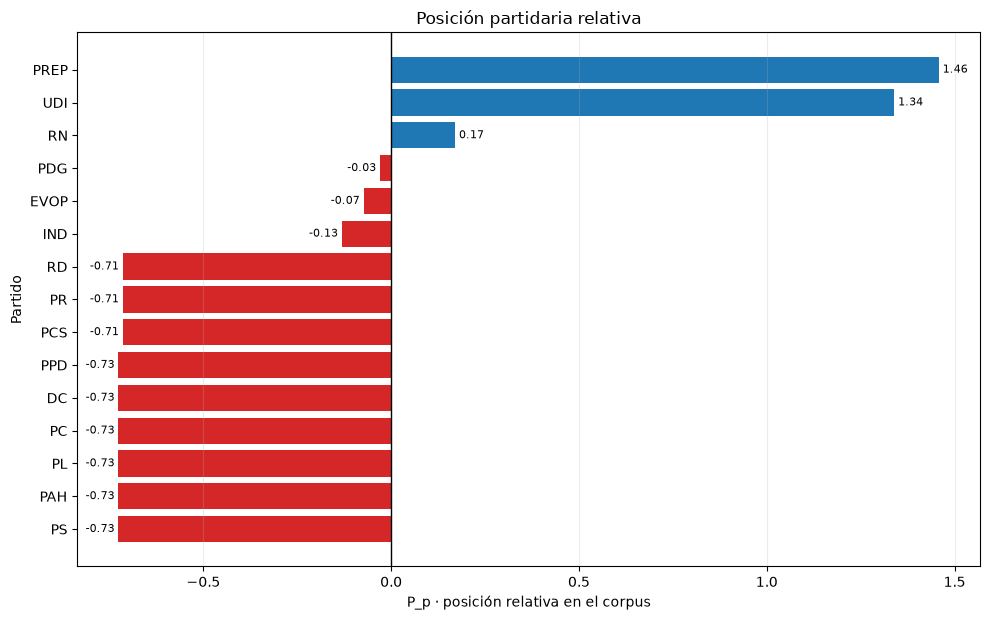

Guardada: F4/figures/partidos_afinidad/posicion_partidaria.png


In [15]:

estimables = partidos.loc[partidos["P_p"].notna()].copy().sort_values("P_p")

fig, ax = plt.subplots(figsize=(10, max(5, 0.42 * len(estimables))))
colors = ["#d62728" if v < 0 else "#1f77b4" for v in estimables["P_p"]]
ax.barh(estimables["partido_alias"], estimables["P_p"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("P_p · posición relativa en el corpus")
ax.set_ylabel("Partido")
ax.set_title("Posición partidaria relativa")
ax.grid(axis="x", alpha=0.25)

for y, v in enumerate(estimables["P_p"]):
    ha = "right" if v < 0 else "left"
    offset = -0.01 if v < 0 else 0.01
    ax.text(v + offset, y, f"{v:.2f}", va="center", ha=ha, fontsize=8)

fig.tight_layout()

ruta_fig = rutas["figuras"] / "posicion_partidaria.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))


### 4.2. Sensibilidad según votación retirada

,votacion_retirada,mediana_delta_abs,max_delta_abs,cambios_publicabilidad
0,20627,0.000542,0.002167,0
1,20628,0.000000,0.000000,0
2,20629,0.002521,0.038122,0
3,20630,0.002984,0.131330,0
4,20631,0.003019,0.008739,0
5,20632,0.004715,0.049665,0
6,20633,0.006151,0.048229,0
7,20634,0.005916,0.048464,0
8,20635,0.004460,0.049919,0
9,20636,0.004460,0.049919,0


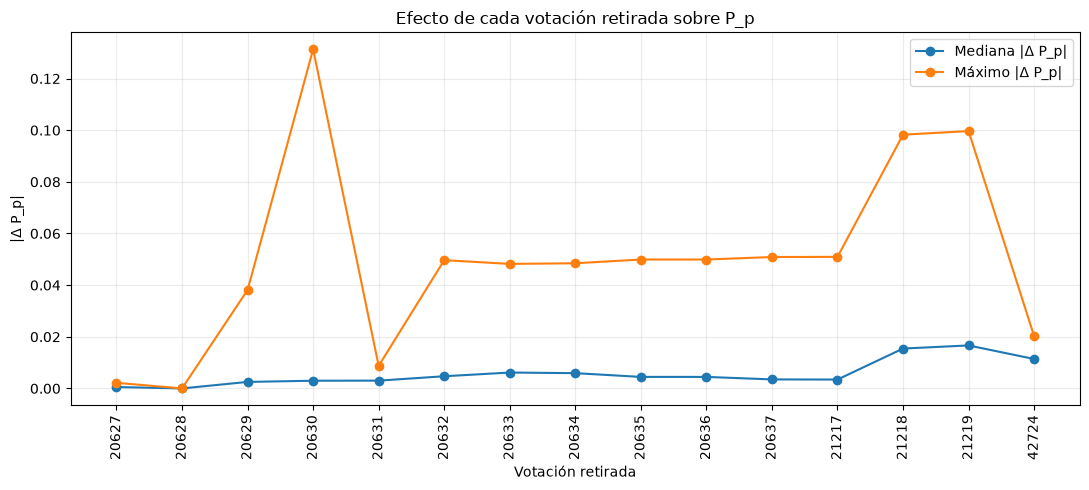

Guardada: F4/figures/partidos_afinidad/sensibilidad_por_votacion.png


In [16]:

por_votacion = (
    sens_60.groupby("votacion_retirada", as_index=False)
    .agg(
        mediana_delta_abs=("diferencia_abs", "median"),
        max_delta_abs=("diferencia_abs", "max"),
        cambios_publicabilidad=("cambio_publicabilidad", lambda x: int(pd.Series(x).fillna(False).astype(bool).sum())),
    )
    .sort_values("votacion_retirada")
)

display(por_votacion)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(por_votacion))
ax.plot(x, por_votacion["mediana_delta_abs"], marker="o", label="Mediana |Δ P_p|")
ax.plot(x, por_votacion["max_delta_abs"], marker="o", label="Máximo |Δ P_p|")
ax.set_xticks(x)
ax.set_xticklabels(por_votacion["votacion_retirada"].astype(str), rotation=90)
ax.set_xlabel("Votación retirada")
ax.set_ylabel("|Δ P_p|")
ax.set_title("Efecto de cada votación retirada sobre P_p")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

ruta_fig = rutas["figuras"] / "sensibilidad_por_votacion.png"
fig.savefig(ruta_fig, dpi=160, bbox_inches="tight")
plt.show()

print("Guardada:", ruta_fig.relative_to(raiz))



## 5. Resumen de artefactos

Este notebook genera las figuras en `F4/figures/partidos_afinidad/`. Las tablas analíticas permanecen en las rutas originales de `data/results` y `data/reports`; el notebook no crea versiones rivales de esos resultados.


In [17]:

figuras_generadas = sorted(p.name for p in rutas["figuras"].glob("*.png"))
display(pd.DataFrame({"figura": figuras_generadas}))

print(f"Total de figuras: {len(figuras_generadas)}")


,figura
0,afinidad_distribucion.png
1,hamming_covotos.png
2,hamming_covotos_rangos.png
3,matriz_hamming.png
4,posicion_partidaria.png
5,posicion_partidaria_dispersion_d1.png
6,posicion_partido_votacion.png
7,sensibilidad_por_votacion.png
8,sensibilidad_posicion_partidaria.png


Total de figuras: 9



## 6. Síntesis interpretativa

- La posición partidaria se reporta con su cobertura efectiva y sin convertir el eje relativo del corpus en una etiqueta política automática.
- La dispersión de `d1` se presenta como heterogeneidad descriptiva y no como cohesión.
- La afinidad entre pares conserva el número de co-votos y excluye de la comparación las celdas no observadas.
- La distancia de Hamming y el acuerdo son complementarios sobre el mismo conjunto de co-votos.
- La sensibilidad leave-one-vote-out permite identificar qué resultados cambian más cuando se retira una votación, sin imponer un umbral universal de estabilidad.
- Los umbrales 40/60/80 se conservan como escenarios metodológicos predefinidos; no se selecciona uno a posteriori por conveniencia visual.
